In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:

def P_vapor(T):
    # T [K]
    # P [Pa]
    return 10**(12.4037 - 8283.1/T - 0.7081*np.log10(T))


In [3]:


def G_max(T):
    # T [K]
    # G [uc]
    
    R = 8.3145 # [J/mol-K]
    g = 10 # [m/s^2]
    pi = 3.141593
    M = 6.941 # [g/mol] 
    
    #uc = 1 # [kg/m^2/s]
    #uc = 360 # [g/cm^2/hour]
    #uc = 0.1 # convert to [g/cm^2/s]
    uc = 0.1 * (6.022e23 / 6.941) # [1/cm^2/s]
    
    return P_vapor(T) / (g * np.sqrt(2*pi*R*T/M)) * uc



In [4]:
def P_evap(T):
    return G_max(T)*146*10**8/6.022e23 

In [5]:
def convConstant(T):
    return P_evap(T)/T

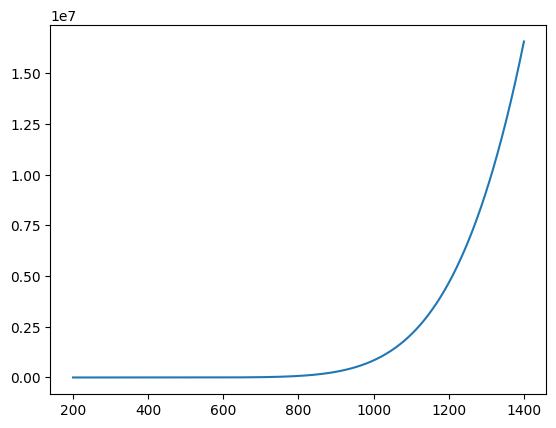

In [12]:
T_all = np.linspace(200,1400,1000)
h = convConstant(273.0 + T_all)

plt.plot(T_all, h)

In [13]:
# Create a DataFrame
df = pd.DataFrame({
    'Temperature_C': T_all,
    'convConstant': h
})

# Export to CSV
df.to_csv('Li_evap.csv', index=False)

# Display the first few rows in the notebook
df.head()

,Temperature_C,convConstant
0,200.000000,0.000074
1,201.201201,0.000082
2,202.402402,0.000090
3,203.603604,0.000099
4,204.804805,0.000109
